<a href="https://colab.research.google.com/github/timmao78/git_demo/blob/main/simple_NeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
#Create a Model Class that inherits nn.Module
class Model(nn.Module):
  # Input layer(4 feature of the flower) -- >
  # Hidden layer1(number of neurons) -->
  # H2(n) -->
  # output(3 classes of iris)
  def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    super().__init__()
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, out_features)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)
    return x


In [4]:
#pick a manual seed for radomization
torch.manual_seed(20)
model = Model()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [7]:
my_df['species'] = my_df['species'].replace('setosa',0.0)
my_df['species'] = my_df['species'].replace('versicolor',1.0)
my_df['species'] = my_df['species'].replace('virginica',2.0)
my_df

/tmp/ipykernel_622/3775887882.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['species'] = my_df['species'].replace('virginica',2.0)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [8]:
# Train Test Split
X = my_df.drop('species', axis=1)
y = my_df['species']

In [9]:
X = X.values
y = y.values

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=20)

In [12]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [13]:
# Set the criteria of model to measure the error, how far off the predictions are from the data
criterion = nn.CrossEntropyLoss()
# Choose Adam Optimizer, lr = larning rate(if error doesn't go down after a bunch of iterations(epochs), lower our learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


In [14]:
#Train our model
#Epochs?(one run thru all the training data in our network)
epochs = 100
losses=[]

for i in range(epochs):
  # Go forward and get a prediction
  y_pred = model.forward(X_train) #Get predicted result

  # Measure the loss/error, gonna be high at first
  loss = criterion(y_pred, y_train)

 # Keep Track of our losses
  losses.append(loss.detach().numpy())

  # print every 10 epoch
  if i%10 == 0:
    print(f"Epoch:{i} and loss: {loss}")

  # Do some back propagation
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()



Epoch:0 and loss: 1.1048375368118286
Epoch:10 and loss: 0.8352535963058472
Epoch:20 and loss: 0.5333452224731445
Epoch:30 and loss: 0.3803027868270874
Epoch:40 and loss: 0.2783735394477844
Epoch:50 and loss: 0.19204112887382507
Epoch:60 and loss: 0.1263255476951599
Epoch:70 and loss: 0.09083087742328644
Epoch:80 and loss: 0.07346073538064957
Epoch:90 and loss: 0.0639343112707138


Text(0.5, 0, 'epoch')

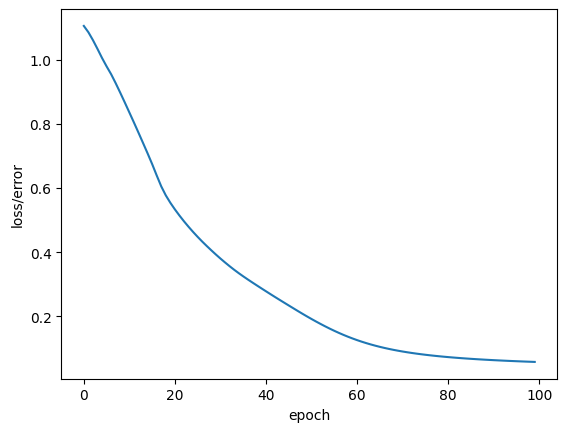

In [15]:
# Graph it out
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel('epoch')

In [16]:
with torch.no_grad():
  y_eval = model.forward(X_test) #X_test are feature from our test set, y_val will be predicitons
  loss = criterion(y_eval, y_test) # find the loss or error
loss

tensor(0.0743)

In [17]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    print(f'{i+1}.) {data} {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}')

    if y_val.argmax().item() == y_test[i]:
      correct += 1
  print(f'We got {correct} correct')

1.) tensor([4.6000, 3.2000, 1.4000, 0.2000]) tensor([  9.5443,   3.6612, -15.5402]) 	 0 	 0
2.) tensor([6.1000, 2.8000, 4.7000, 1.2000]) tensor([-2.8127,  5.0112,  1.0776]) 	 1 	 1
3.) tensor([6.4000, 2.9000, 4.3000, 1.3000]) tensor([-1.4777,  5.5927, -1.1579]) 	 1 	 1
4.) tensor([7.2000, 3.0000, 5.8000, 1.6000]) tensor([-5.6795,  4.2858,  5.6519]) 	 2 	 2
5.) tensor([5.8000, 2.7000, 4.1000, 1.0000]) tensor([-0.7597,  5.3344, -2.0454]) 	 1 	 1
6.) tensor([5.5000, 2.5000, 4.0000, 1.3000]) tensor([-2.2615,  4.6772,  0.5307]) 	 1 	 1
7.) tensor([6.8000, 3.2000, 5.9000, 2.3000]) tensor([-7.9733,  2.8990,  9.8176]) 	 2 	 2
8.) tensor([5.1000, 3.7000, 1.5000, 0.4000]) tensor([ 10.2606,   3.9115, -16.7095]) 	 0 	 0
9.) tensor([6.7000, 2.5000, 5.8000, 1.8000]) tensor([-7.6124,  2.7513,  9.4041]) 	 2 	 2
10.) tensor([4.8000, 3.0000, 1.4000, 0.1000]) tensor([  9.6916,   3.6522, -15.7224]) 	 0 	 0
11.) tensor([6.5000, 3.0000, 5.2000, 2.0000]) tensor([-5.8109,  3.6755,  6.2471]) 	 2 	 2
12.) tenso

In [18]:
new_iris = torch.tensor([4.7, 3.2, 1.3, 0.2])
new_iris

tensor([4.7000, 3.2000, 1.3000, 0.2000])

In [19]:
with torch.no_grad():
  print(model(new_iris))

tensor([  9.7166,   3.6559, -15.7672])


In [20]:
# Save our NN Model
torch.save(model.state_dict(), 'my_really_awesome_iris_model.pt')

In [21]:
# Load the Saved model
new_model = Model()
new_model.load_state_dict(torch.load('my_really_awesome_iris_model.pt'))

<All keys matched successfully>

In [22]:
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)